# EDA Completa — National Highway Planning Network (NHPN)

### Autor: Lucca Maximus Romagnolli Soares — Universidade de Brasília

## Objetivo

Realizar uma análise exploratória completa do dataset `NTAD_National_Highway_Planning_Network_-129350642200434263.csv`, com foco em:

- extensão por categoria funcional (`F_SYSTEM`)
- densidade da malha por estado (nomes dos estados)
- corredores principais (`SIGN1`/`SIGNT1`)
- participação do NHS (`NHS`)
- sugestões de aplicações práticas para engenharia e planejamento

## Datacard — National Highway Planning Network (NHPN)

**Base de rodovias dos EUA · Federal Highway Administration (FHWA) · USDOT / Bureau of Transportation Statistics**

---

### Visão geral

| | |
|---|---|
| **Registros (trechos viários)** | 626.366 |
| **Variáveis disponíveis** | 46 colunas por registro |
| **Cobertura territorial** | 48 estados + DC, Alasca, Havaí e Porto Rico |
| **Unidade de análise** | Segmento de rodovia com características homogêneas |
| **Escala nominal** | 1:100.000 · erro posicional máximo de 80 m |

---

### O que esta base representa

Cada linha corresponde a um **segmento de rodovia** — um trecho contínuo com características homogêneas de classificação, sinalização e jurisdição. A extensão de cada trecho é registrada em milhas e quilômetros. O campo `YEAR_RECOR` indica o ano de registro de cada segmento.

---

### Grupos de informação

**Classificação funcional**
Tipo da via: Interestadual, Arterial Urbana, Arterial Rural etc.
Campos: `F_SYSTEM`, `FCLASS`, `STATUS`

**Localização administrativa**
Identificação por estado e condado via código FIPS.
Campos: `STFIPS`, `CTFIPS`

**Sinalização e rota**
Nome e tipo da rota sinalizada (ex.: I-95, US-1).
Campos: `SIGN1`, `SIGNT1`, `SIGNN1`, `SIGNQ1`

**Rede estratégica**
Participação nos sistemas nacionais prioritários.
Campos: `NHS`, `STRAHNET`

**Contexto urbano/rural**
Classificação do entorno: zona urbana grande, pequena ou rural.
Campos: `URBAN_CODE`, `RUCODE`, `LGURB`, `SMURB`

---

### Perguntas orientadoras da análise

1. Como a extensão total da malha se distribui entre as diferentes classes funcionais de rodovias?
2. Quais estados concentram a maior extensão de rodovias no país?
3. Qual é o peso dos corredores principais (Interestaduais e US Highways) e da rede NHS sobre o total?

---

### Pontos de atenção

> **Códigos técnicos** — Diversas colunas usam códigos numéricos que precisam de mapeamento para leitura humana. Este processo já está aplicado nas visualizações do notebook.

> **Geometria** — Para análises de conectividade e topologia de rede, recomenda-se integrar com o arquivo vetorial original (shapefile ou GeoJSON).

---

### Fonte e metadados oficiais

| | |
|---|---|
| **Instituição responsável** | Federal Highway Administration (FHWA) — USDOT / Bureau of Transportation Statistics |
| **Compilação da base** | 1º de maio de 2014 |
| **Última atualização de metadados** | 17 de julho de 2025 |
| **Escala nominal** | 1:100.000 · erro posicional máximo de 80 m |
| **Dicionário de dados (DOI)** | https://doi.org/10.21949/1529044 |
| **Catálogo oficial** | https://catalog.data.gov/dataset/national-highway-planning-network1 |

## Importação das bibliotecas e configuração

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Resolve a raiz do projeto de forma robusta
_raiz_atual = Path.cwd().resolve()
PROJETO_RAIZ = next((p for p in [_raiz_atual, *_raiz_atual.parents] if (p / 'datasets').exists()), _raiz_atual)

DATA_PATH = PROJETO_RAIZ / 'datasets' / 'NTAD_National_Highway_Planning_Network_-129350642200434263.csv'
print('PROJETO_RAIZ:', PROJETO_RAIZ)
print('DATA_PATH:', DATA_PATH)

# Diretório padrão para salvar os gráficos deste notebook
GRAPHS_DIR = PROJETO_RAIZ / 'notebooks' / 'usa-highways' / 'graphs'
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)
print('GRAPHS_DIR:', GRAPHS_DIR)

def save_fig(fig, filename: str, **kwargs):
    out = GRAPHS_DIR / filename
    fig.savefig(out, bbox_inches='tight', **kwargs)
    return out

# Mapeamentos para converter STFIPS em abreviacao e nome do estado
fips_to_abbr = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC',
    12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 19: 'IA', 20: 'KS',
    21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY',
    37: 'NC', 38: 'ND', 39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC',
    46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY', 72: 'PR'
}

fips_to_state = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California', 8: 'Colorado',
    9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia', 12: 'Florida', 13: 'Georgia',
    15: 'Hawaii', 16: 'Idaho', 17: 'Illinois', 18: 'Indiana', 19: 'Iowa', 20: 'Kansas',
    21: 'Kentucky', 22: 'Louisiana', 23: 'Maine', 24: 'Maryland', 25: 'Massachusetts',
    26: 'Michigan', 27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey', 35: 'New Mexico',
    36: 'New York', 37: 'North Carolina', 38: 'North Dakota', 39: 'Ohio', 40: 'Oklahoma',
    41: 'Oregon', 42: 'Pennsylvania', 44: 'Rhode Island', 45: 'South Carolina',
    46: 'South Dakota', 47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont',
    51: 'Virginia', 53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin', 56: 'Wyoming',
    72: 'Puerto Rico'
}

PROJETO_RAIZ: /Users/luccaromagnolli/Desktop/Civil-Engineering
DATA_PATH: /Users/luccaromagnolli/Desktop/Civil-Engineering/datasets/NTAD_National_Highway_Planning_Network_-129350642200434263.csv


## Carregamento e visão geral da base

In [3]:
df = pd.read_csv(DATA_PATH)

print(f'Linhas: {len(df):,}')
print(f'Colunas: {df.shape[1]}')

display(df.head(3))
display(df.info())

Linhas: 626,366
Colunas: 46


,OBJECTID,YEAR_RECOR,ROUTE_ID,BEGIN_POIN,END_POINT,F_SYSTEM,FACILITY_T,URBAN_CODE,RECTYPE,VERSION,RECID,ORIGID,CTFIPS,SOURCE,LGURB,SMURB,SIGN1,SIGNT1,SIGNN1,SIGNQ1,SIGN2,SIGNT2,SIGNN2,SIGNQ2,SIGN3,SIGNT3,SIGNN3,SIGNQ3,LNAME,MILES,KM,FCLASS,RUCODE,STATUS,NHS,STRAHNET,FAC_ID,CONN_ID,CONN_DES,CONN_MILES,LRSKEY,LRSSEQ,BEGMP,ENDMP,STFIPS,Shape__Length
0,1,2011,150000,157.020,176.061,3,2,99999,L,"2,014.050",2002148,2002148,290,H,0,0,S65,S,65,,,,,,,,,,JAMES DALTON HWY,18.070,29.081,2,1,1,7,0,,,,0.000,001500000000002,2,75.236,193.382,2,0.395
1,2,2010,50,0.493,0.931,3,2,99998,L,"2,014.050",15001104,15001104,7,H,0,0,S50,S,50,,,,,,,,,,KAUMUALII HWY,0.428,0.689,6,2,1,7,0,,,,0.000,000000005000007,10,30.895,31.953,15,0.007
2,3,2010,583,0.920,3.920,5,2,99999,L,"2,014.050",15001103,15001103,7,H,0,0,S583,S,583,,,,,,,,,,MAALO RD,2.404,3.869,0,1,1,0,0,,,,0.000,,0,0.000,0.000,15,0.036


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626366 entries, 0 to 626365
Data columns (total 46 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OBJECTID       626366 non-null  int64  
 1   YEAR_RECOR     626366 non-null  int64  
 2   ROUTE_ID       626366 non-null  object 
 3   BEGIN_POIN     626366 non-null  float64
 4   END_POINT      626366 non-null  float64
 5   F_SYSTEM       626366 non-null  int64  
 6   FACILITY_T     626366 non-null  int64  
 7   URBAN_CODE     626366 non-null  int64  
 8   RECTYPE        626366 non-null  object 
 9   VERSION        626366 non-null  float64
 10  RECID          626366 non-null  int64  
 11  ORIGID         626366 non-null  int64  
 12  CTFIPS         626366 non-null  int64  
 13  SOURCE         626366 non-null  object 
 14  LGURB          626366 non-null  int64  
 15  SMURB          626366 non-null  int64  
 16  SIGN1          626359 non-null  object 
 17  SIGNT1         626366 non-nul

None

## Qualidade de dados e consistência inicial

,pct_nulos
Shape__Length,0.002
SIGNN1,0.001
SIGN1,0.001
SIGN3,0.000
SIGNN3,0.000
SIGNQ3,0.000
LNAME,0.000
MILES,0.000
KM,0.000
FCLASS,0.000


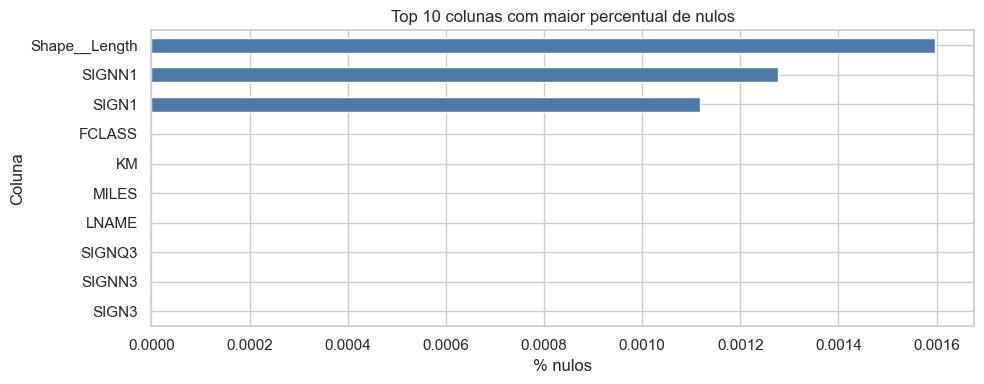

Resumo de unicidade de chaves/códigos:
 - ROUTE_ID: 34,219 valores únicos
 - RECID: 626,349 valores únicos
 - OBJECTID: 626,366 valores únicos
 - FAC_ID: 1,217 valores únicos
 - LRSKEY: 32,590 valores únicos


In [4]:
faltantes = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename('pct_nulos')
      .to_frame()
)

display(faltantes.head(10))

fig, ax = plt.subplots(figsize=(10, 4))
(faltantes.head(10)
 .sort_values('pct_nulos')
 .plot(kind='barh', y='pct_nulos', legend=False, ax=ax, color='#4e79a7'))
ax.set_title('Top 10 colunas com maior percentual de nulos')
ax.set_xlabel('% nulos')
ax.set_ylabel('Coluna')
plt.tight_layout()
save_fig(fig, 'top10_nulls_pct.png')
plt.show()

print('Resumo de unicidade de chaves/códigos:')
for col in ['ROUTE_ID', 'RECID', 'OBJECTID', 'FAC_ID', 'LRSKEY']:
    if col in df.columns:
        print(f' - {col}: {df[col].nunique():,} valores únicos')

## 1) Extensão por categoria funcional (`F_SYSTEM`)

Mapeamento de referência comum:

- `1`: Interstate - Interestadual
- `2`: Other Freeways and Expressways - Outras Rodovias e Vias Expressas
- `3`: Other Principal Arterial - Outras Arteriais Principais
- `4`: Minor Arterial - Arterial Secundária
- `5`: Major Collector - Coletora Principal
- `6`: Minor Collector - Coletora Secundária
- `7`: Local
- `0`: sem classificação/indefinido

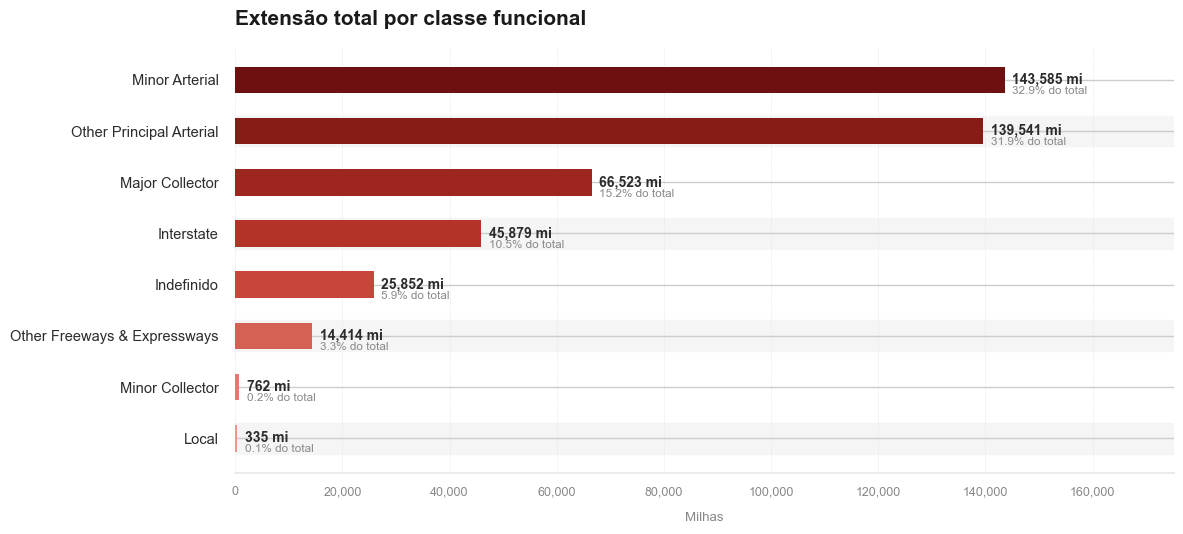

Salvo: nhpn_fsystem_extensao.png


In [26]:
# ── Preparação: extensão por F_SYSTEM ────────────────────────────────
f_system_labels = {
    1: 'Interstate',
    2: 'Other Freeways & Expressways',
    3: 'Other Principal Arterial',
    4: 'Minor Arterial',
    5: 'Major Collector',
    6: 'Minor Collector',
    7: 'Local',
    0: 'Indefinido'
}
extensao_fsystem = (
    df.groupby('F_SYSTEM', dropna=False)
      .agg(MILES=('MILES', 'sum'), KM=('KM', 'sum'))
      .assign(classe=lambda d: d.index.map(lambda x: f_system_labels.get(int(x), 'Outra')))
      .sort_values('MILES', ascending=False)
)
extensao_fsystem['pct_miles'] = 100 * extensao_fsystem['MILES'] / extensao_fsystem['MILES'].sum()

# ── Estilo ────────────────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

TYPE_COLORS = {'I': '#6E1010', 'US': '#C0392B', 'S': '#F1948A'}
cmap_red = LinearSegmentedColormap.from_list(
    'red_op2', [TYPE_COLORS['S'], TYPE_COLORS['US'], TYPE_COLORS['I']]
)

BG     = '#FFFFFF'
DARK   = '#1A1A1A'
MID    = '#2C2C2C'
SUBTLE = '#888888'
GRID   = '#E8E8E8'

plot_df = extensao_fsystem.reset_index().sort_values('MILES', ascending=True)
n = len(plot_df)
palette = [cmap_red(i / (n - 1)) for i in range(n)]

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(
    plot_df['classe'],
    plot_df['MILES'],
    color=palette,
    height=0.52,
    edgecolor='none',
)

# Faixas zebradas
for i, bar in enumerate(bars):
    if i % 2 == 0:
        ax.axhspan(
            bar.get_y() - 0.04,
            bar.get_y() + bar.get_height() + 0.04,
            color='#F5F5F5', zorder=0
        )

ax.xaxis.grid(True, linestyle='--', linewidth=0.45, color=GRID, alpha=1, zorder=0)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Rótulos: valor + percentual
for bar, val, pct in zip(bars, plot_df['MILES'], plot_df['pct_miles']):
    ax.text(
        bar.get_width() + plot_df['MILES'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.0f} mi',
        va='center', ha='left',
        fontsize=10, color=MID, fontweight='bold'
    )
    ax.text(
        bar.get_width() + plot_df['MILES'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2 - 0.22,
        f'{pct:.1f}% do total',
        va='center', ha='left',
        fontsize=8.5, color=SUBTLE
    )

ax.set_title(
    'Extensão total por classe funcional',
    fontsize=15, fontweight='bold', color=DARK,
    pad=16, loc='left', x=0.0
)
ax.set_xlabel('Milhas', fontsize=9.5, color=SUBTLE, labelpad=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10.5, colors=MID, pad=6)
ax.tick_params(axis='x', labelsize=9, colors=SUBTLE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(right=plot_df['MILES'].max() * 1.22)

plt.tight_layout()

fig.savefig(
    'nhpn_fsystem_extensao.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=BG,
    transparent=False
)
plt.show()
print("Salvo: nhpn_fsystem_extensao.png")

## 2) Densidade rodoviária por estado

Nesta base, calculamos **extensão absoluta** por estado. Para densidade real (km por área), recomenda-se integrar a área territorial por estado (Census).

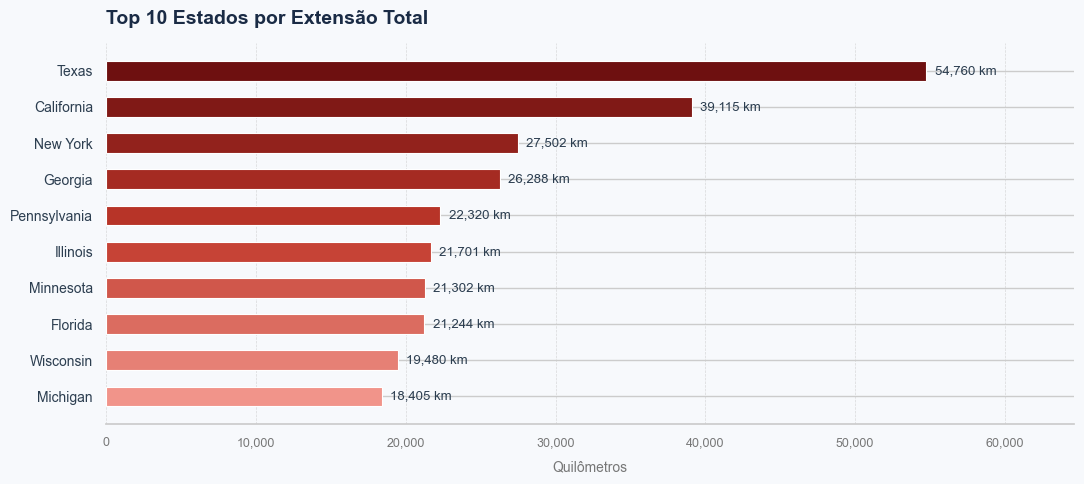

In [18]:
# ── Preparação: extensão por estado (STFIPS) ─────────────────────────
extensao_estado = (
    df.groupby('STFIPS', dropna=False)
      .agg(MILES=('MILES', 'sum'), KM=('KM', 'sum'))
      .sort_values('KM', ascending=False)
)
extensao_estado_nome = (
    extensao_estado
    .reset_index()
    .assign(estado=lambda d: d['STFIPS'].map(fips_to_state).fillna('Desconhecido'))
    .sort_values('KM', ascending=False)
)
# ── Plot ─────────────────────────────────────────────────────────────
BG     = '#F7F9FC'
DARK   = '#1A2B45'
MID    = '#2C3E50'
SUBTLE = '#777777'
GRID   = '#CCCCCC'

# Opção 2 — Quente e contrastante
TYPE_COLORS = {
    'I':  '#6E1010',   # Interstate   — borgonha profundo
    'US': '#C0392B',   # US Highway   — vermelho vivo
    'S':  '#F1948A',   # State        — salmão claro
}

top10_estados = extensao_estado_nome.head(10).sort_values('KM', ascending=True)

# Gradiente contínuo entre borgonha e salmão (do menor para o maior valor)
from matplotlib.colors import LinearSegmentedColormap
cmap_red = LinearSegmentedColormap.from_list(
    'red_op2', [TYPE_COLORS['S'], TYPE_COLORS['US'], TYPE_COLORS['I']]
)
palette = [cmap_red(i / (len(top10_estados) - 1)) for i in range(len(top10_estados))]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
bars = ax.barh(
    top10_estados['estado'],
    top10_estados['KM'],
    color=palette,
    height=0.55,
    edgecolor='white',
    linewidth=0.8
)
ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, top10_estados['KM']):
    ax.text(
        bar.get_width() + top10_estados['KM'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.0f} km',
        va='center', ha='left',
        fontsize=9.5, color=MID, fontweight='500'
    )
ax.set_title('Top 10 Estados por Extensão Total', fontsize=14, fontweight='bold',
             color=DARK, pad=14, loc='left')
ax.set_xlabel('Quilômetros', fontsize=10, color=SUBTLE, labelpad=8)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10, colors=MID)
ax.tick_params(axis='x', labelsize=9,  colors=SUBTLE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(right=top10_estados['KM'].max() * 1.18)
plt.tight_layout()
plt.show()

## 3) Identificação de corredores principais (`SIGN1`/`SIGNT1`)

Nesta etapa, usamos os campos de sinalização para identificar o tipo de corredor:

- `SIGNT1` indica o **sistema da rota**.
  - `I` = **Interstate Highway** (rede interestadual de alta capacidade, padrão federal)
  - `US` = **U.S. Highway** (rede federal tradicional, geralmente conectando cidades/regiões)
  - `S` = **State Highway** (rodovia estadual)
- `SIGN1` traz o identificador da rota (ex.: `I95`, `US1`, `S65`).

Para o recorte de corredores principais, vamos considerar `SIGNT1` em `{I, US}` e comparar sua participação em quantidade de trechos e extensão total.

,SIGNT1_NORM,tipo,trechos,MILES,pct_trechos,pct_miles
1,S,State Highway,250111,"212,938.115",39.930,48.739
0,I,Interstate,96892,"46,652.531",15.469,10.678


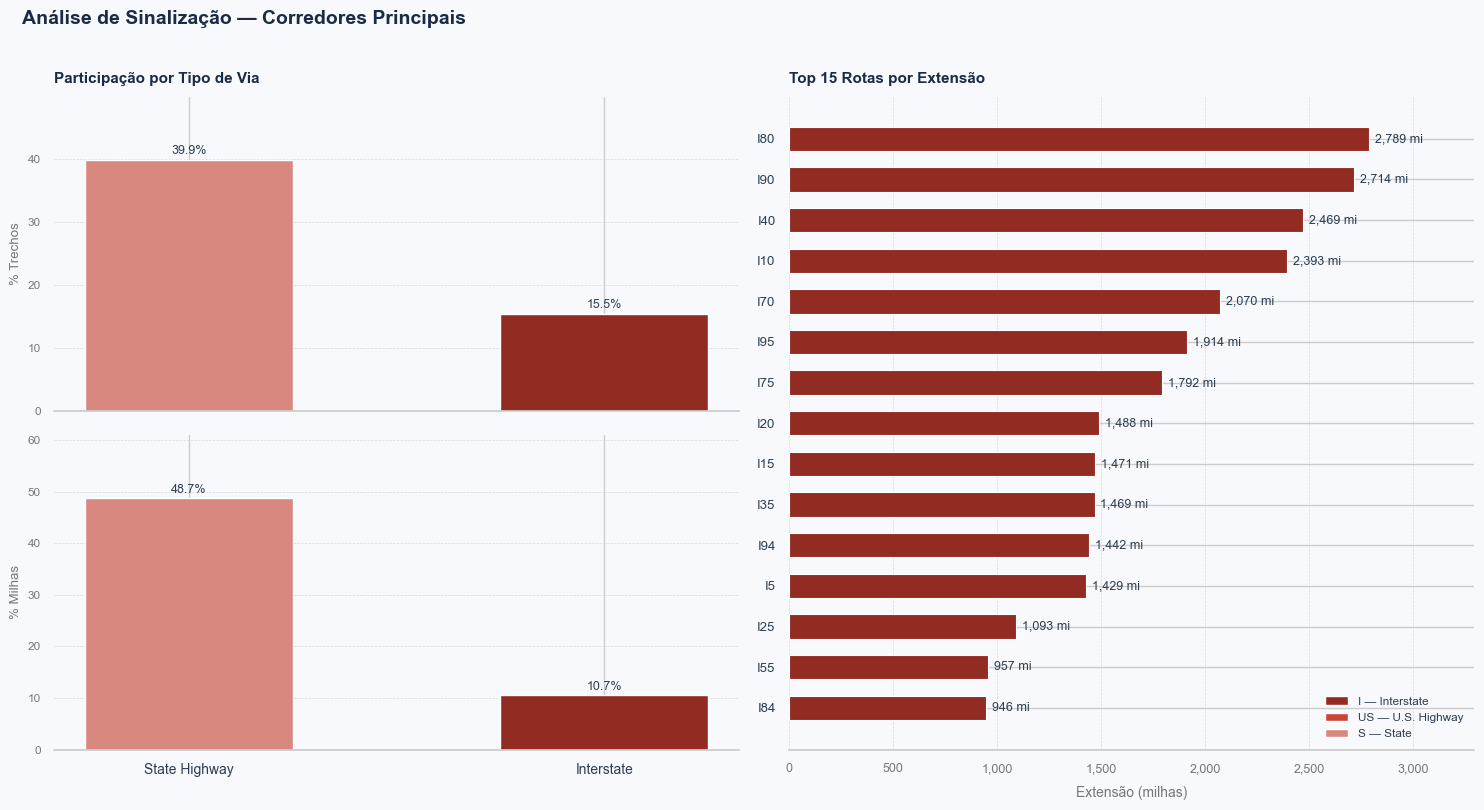

In [16]:
tipos_principais = {'I', 'US'}
tipos_explicacao = {'I': 'Interstate', 'US': 'U.S. Highway', 'S': 'State Highway'}

# Normaliza SIGNT1 para evitar diferenças de caixa/espaços
sign_norm = df['SIGNT1'].astype(str).str.upper().str.strip()

# Resumo por tipo de sinalização
resumo_sinalizacao = (
    df.assign(SIGNT1_NORM=sign_norm)
      .loc[lambda d: d['SIGNT1_NORM'].isin(tipos_explicacao)]
      .groupby('SIGNT1_NORM', dropna=False)
      .agg(trechos=('SIGNT1_NORM', 'size'), MILES=('MILES', 'sum'), KM=('KM', 'sum'))
      .reset_index()
)
resumo_sinalizacao['tipo'] = resumo_sinalizacao['SIGNT1_NORM'].map(tipos_explicacao)
resumo_sinalizacao['pct_trechos'] = 100 * resumo_sinalizacao['trechos'] / len(df)
resumo_sinalizacao['pct_miles'] = 100 * resumo_sinalizacao['MILES'] / df['MILES'].sum()

display(
    resumo_sinalizacao[['SIGNT1_NORM', 'tipo', 'trechos', 'MILES', 'pct_trechos', 'pct_miles']]
    .sort_values('MILES', ascending=False)
)

# Corredores principais (I/US)
corredores = df.loc[sign_norm.isin(tipos_principais)].copy()
share_trechos = len(corredores) / len(df)
share_milhas = corredores['MILES'].sum() / df['MILES'].sum()

# Top rotas (SIGN1) dentro de cada tipo principal
rotas_top = (
    corredores.assign(SIGNT1=sign_norm)
      .groupby(['SIGNT1', 'SIGN1'], dropna=False)
      .agg(MILES=('MILES', 'sum'), trechos=('SIGN1', 'size'))
      .reset_index()
      .sort_values('MILES', ascending=False)
      .head(15)
)


# ── Paleta executiva ──────────────────────────────────────────────
BG      = '#F7F9FC'
DARK    = '#1A2B45'
MID     = '#2C3E50'
SUBTLE  = '#777777'
GRID    = '#CCCCCC'


# Opção 2 — Quente e contrastante
TYPE_COLORS = {
    'I':  '#922B21',   # Interstate   — vermelho tijolo
    'US': '#CB4335',   # US Highway   — terracota médio
    'S':  '#D98880',   # State        — rosê suave
}

fig = plt.figure(figsize=(15, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Análise de Sinalização — Corredores Principais',
             fontsize=14, fontweight='bold', color=DARK, x=0.02, ha='left', y=1.01)

# 2 linhas na coluna esquerda, 1 bloco na coluna direita
ax_top = plt.subplot2grid((2, 2), (0, 0))   # % Trechos
ax_bot = plt.subplot2grid((2, 2), (1, 0))   # % Milhas
ax2    = plt.subplot2grid((2, 2), (0, 1), rowspan=2)  # Top 15 rotas

rs = resumo_sinalizacao.sort_values('MILES', ascending=False)
tipos  = rs['tipo'].tolist()
colors = [TYPE_COLORS.get(t, '#AEB6BF') for t in rs['SIGNT1_NORM']]
x      = range(len(rs))

for ax, col, label in [
    (ax_top, 'pct_trechos', '% Trechos'),
    (ax_bot, 'pct_miles',   '% Milhas'),
]:
    ax.set_facecolor(BG)
    bars = ax.bar(x, rs[col], color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, rs[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color=MID)
    ax.set_xticks(list(x))
    ax.set_xticklabels(tipos if ax == ax_bot else ['']*len(tipos),
                       fontsize=10, color=MID)
    ax.set_ylabel(label, fontsize=9.5, color=SUBTLE)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(axis='x', colors=MID)
    ax.tick_params(axis='y', colors=SUBTLE, labelsize=8.5)
    ax.set_ylim(0, rs[col].max() * 1.25)

ax_top.set_title('Participação por Tipo de Via', fontsize=11, fontweight='bold',
                 color=DARK, loc='left', pad=10)

# PAINEL DIREITO — Top 15 rotas

ax2.set_facecolor(BG)
rt = rotas_top.sort_values('MILES', ascending=True)
bar_colors = [TYPE_COLORS.get(t, '#AEB6BF') for t in rt['SIGNT1']]

bars = ax2.barh(rt['SIGN1'].astype(str), rt['MILES'],
                color=bar_colors, height=0.6, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, rt['MILES']):
    ax2.text(bar.get_width() + rt['MILES'].max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f} mi', va='center', fontsize=9, color=MID)

ax2.set_title('Top 15 Rotas por Extensão', fontsize=11, fontweight='bold',
              color=DARK, loc='left', pad=10)
ax2.set_xlabel('Extensão (milhas)', fontsize=10, color=SUBTLE, labelpad=8)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.xaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.spines['bottom'].set_color(GRID)
ax2.tick_params(axis='y', labelsize=9.5, colors=MID)
ax2.tick_params(axis='x', labelsize=9, colors=SUBTLE)
ax2.set_xlim(right=rt['MILES'].max() * 1.18)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=k + ' — ' + {'I':'Interstate','US':'U.S. Highway','S':'State'}.get(k,''))
              for k, v in TYPE_COLORS.items()]
ax2.legend(handles=legend_els, fontsize=8.5, framealpha=0, labelcolor=MID, loc='lower right')

plt.tight_layout()
plt.show()


## 4) Estudo do NHS (`NHS`)

NHS significa *National Highway System* — o Sistema Nacional de Rodovias dos EUA. É uma rede de estradas consideradas estratégicas para o país, classificadas em diferentes categorias conforme sua função e relevância nacional.

### NHS 0 — Não-NHS

Rodovias fora do Sistema Nacional de Rodovias.

**Interpretação:** mais de 3 em cada 5 milhas da malha catalogada no NHPN **não** integram o NHS. Isso representa a vasta rede de rodovias estaduais, coletoras e locais que complementam os corredores federais.

### NHS 7 — NHS Estratégico (STRAHNET)

*Strategic Highway Network* (STRAHNET), com foco em suporte a mobilizações militares e defesa nacional.

**Interpretação:** é o segundo maior grupo da rede, acima inclusive do NHS Principal. Inclui rotas designadas pelo Departamento de Defesa como essenciais para movimentação de tropas e equipamentos. Muitas coincidem com Interstates, mas também existem corredores estratégicos não interestaduais.

### NHS 1 — NHS Principal

*National Highway System*, rede principal de interesse nacional.

**Interpretação:** é o núcleo do sistema federal de rodovias. Concentra fluxos de comércio interestadual e conectividade entre grandes centros urbanos. Embora represente cerca de 11% da extensão, tende a concentrar alta prioridade de financiamento federal.

### NHS 3 — NHS Conexão

Rotas de conexão entre o NHS e terminais, portos e instalações estratégicas.

**Interpretação:** são rotas de acesso que conectam o NHS principal a aeroportos, portos marítimos, terminais ferroviários e instalações militares. Têm papel relevante para a logística de última milha do sistema federal.



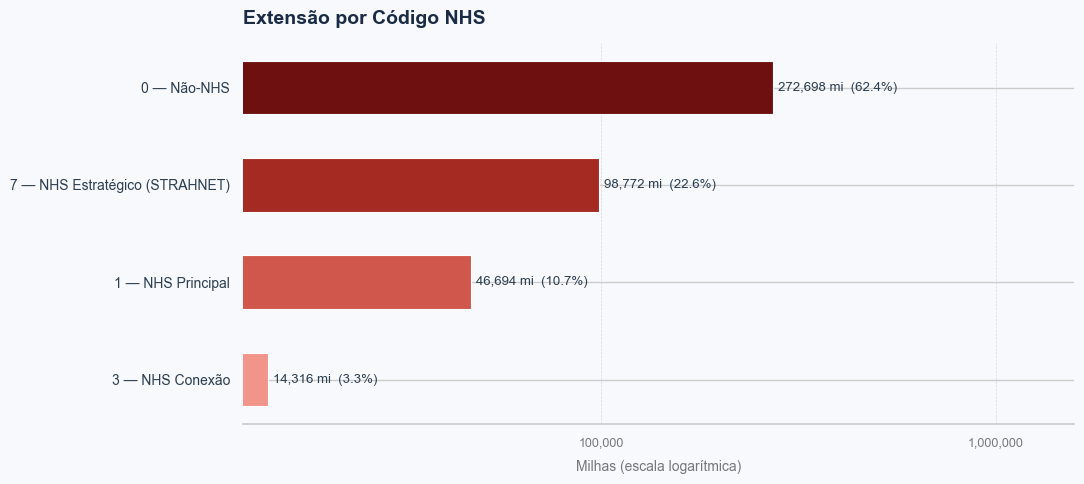

In [17]:
# ── Preparação: extensão por código NHS ─────────────────────────────
nhs_ext = (
    df.groupby('NHS', dropna=False)
      .agg(MILES=('MILES', 'sum'), trechos=('NHS', 'size'))
      .sort_values('MILES', ascending=False)
)
nhs_ext['pct_miles'] = 100 * nhs_ext['MILES'] / nhs_ext['MILES'].sum()
nhs_labels = {
    0: '0 — Não-NHS',
    1: '1 — NHS Principal',
    3: '3 — NHS Conexão',
    7: '7 — NHS Estratégico (STRAHNET)'
}
nhs_plot = (
    nhs_ext.reset_index()
           .assign(label=lambda d: d['NHS'].map(lambda x: nhs_labels.get(int(x), f"{int(x)} — Outro")))
)
# ── Plot ─────────────────────────────────────────────────────────────
BG     = '#F7F9FC'
DARK   = '#1A2B45'
MID    = '#2C3E50'
SUBTLE = '#777777'
GRID   = '#CCCCCC'

# Opção 2 — Quente e contrastante
TYPE_COLORS = {
    'I':  '#6E1010',
    'US': '#C0392B',
    'S':  '#F1948A',
}

nhs_plot_sorted = nhs_plot.sort_values('MILES', ascending=True).tail(4)

from matplotlib.colors import LinearSegmentedColormap
cmap_red = LinearSegmentedColormap.from_list(
    'red_op2', [TYPE_COLORS['S'], TYPE_COLORS['US'], TYPE_COLORS['I']]
)
palette = [cmap_red(i / (len(nhs_plot_sorted) - 1)) for i in range(len(nhs_plot_sorted))]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
bars = ax.barh(
    nhs_plot_sorted['label'],
    nhs_plot_sorted['MILES'],
    color=palette,
    height=0.55,
    edgecolor='white',
    linewidth=0.8
)
ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
ax.set_axisbelow(True)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val, pct in zip(bars, nhs_plot_sorted['MILES'], nhs_plot_sorted['pct_miles']):
    ax.text(
        bar.get_width() * 1.03,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.0f} mi  ({pct:.1f}%)',
        va='center', ha='left',
        fontsize=9.5, color=MID, fontweight='500'
    )
ax.set_title('Extensão por Código NHS', fontsize=14, fontweight='bold',
             color=DARK, pad=14, loc='left')
ax.set_xlabel('Milhas (escala logarítmica)', fontsize=10, color=SUBTLE, labelpad=8)
ax.tick_params(axis='y', labelsize=10, colors=MID)
ax.tick_params(axis='x', labelsize=9,  colors=SUBTLE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(right=ax.get_xlim()[1] * 5)
plt.tight_layout()
plt.show()

## 6) Visualização geoespacial (agregada por estado)

Este CSV não traz geometria linha a linha (WKT/lat-lon), mas podemos mapear a intensidade por estado usando o nome (ou a sigla) de cada estado nas visualizações.

In [19]:
# ── Mapa coroplético por estado (extensão em KM) ─────────────────────
import plotly.express as px
import plotly.graph_objects as go

estado_mapa = extensao_estado.reset_index().copy()
estado_mapa['state_abbr'] = estado_mapa['STFIPS'].map(fips_to_abbr)
estado_mapa['state_name'] = estado_mapa['STFIPS'].map(fips_to_state)
estado_mapa = estado_mapa.dropna(subset=['state_abbr'])

# ── Paleta opção 2 invertida (branco → borgonha) ─────────────────────
colorscale = [
    [0.00, '#FDF2F2'],
    [0.25, '#F1948A'],
    [0.55, '#C0392B'],
    [1.00, '#6E1010'],
]

fig = px.choropleth(
    estado_mapa,
    locations='state_abbr',
    locationmode='USA-states',
    color='KM',
    scope='usa',
    color_continuous_scale=colorscale,
    hover_name='state_name',
    hover_data={
        'state_abbr': False,
        'KM':    ':,.0f',
        'MILES': ':,.0f',
    },
    labels={'KM': 'Extensão (km)', 'MILES': 'Extensão (mi)'},
)

fig.update_traces(
    marker_line_color='white',
    marker_line_width=0.6,
    hovertemplate=(
        '<b>%{hovertext}</b><br>'
        'Extensão: %{z:,.0f} km<br>'
        '<extra></extra>'
    )
)

fig.update_layout(
    title=dict(
        text='Extensão rodoviária total por estado',
        font=dict(size=17, color='#1A1A1A', family='Arial'),
        x=0.03, xanchor='left', y=0.97
    ),
    annotations=[dict(
        text='Fonte: Federal Highway Administration (FHWA) · NTAD / USDOT',
        x=0.03, y=-0.05,
        xref='paper', yref='paper',
        showarrow=False,
        font=dict(size=9, color='#888888'),
        xanchor='left'
    )],
    geo=dict(
        showlakes=True,
        lakecolor='#EAF4FB',
        showland=True,
        landcolor='#F9F9F9',
        showframe=False,
        bgcolor='#FFFFFF',
    ),
    coloraxis_colorbar=dict(
        title=dict(text='km', font=dict(size=11, color='#555555')),
        tickformat=',.0f',
        tickfont=dict(size=10, color='#555555'),
        len=0.55,
        thickness=14,
        x=1.01,
        bgcolor='rgba(0,0,0,0)',
        outlinewidth=0,
    ),
    margin=dict(l=0, r=0, t=60, b=40),
    paper_bgcolor='#FFFFFF',
    plot_bgcolor='#FFFFFF',
    font=dict(family='Arial'),
)

# ── Exportar PNG para GitHub ──────────────────────────────────────────
try:
    fig.write_image('nhpn_mapa_estados.png', width=1100, height=620, scale=2)
    print("Salvo: nhpn_mapa_estados.png")
except Exception:
    print("kaleido não instalado — rode: pip install kaleido")

fig.show()

kaleido não instalado — rode: pip install kaleido


## 7) Análise Rural vs. Urbano (`URBAN_CODE` / `RUCODE`)

Consideramos `URBAN_CODE == 99999` como **rural** e os demais valores como **urbano**. A análise abaixo compara quantidade de segmentos, extensão total e extensão média por segmento, além de cruzar com `F_SYSTEM` para identificar classes dominantes em cada contexto territorial.

,area_tipo,classe,segmentos,miles_total,pct_miles_area
4,Rural,Minor Arterial,95647,"123,078.711",39.879
3,Rural,Other Principal Arterial,79372,"85,861.237",27.820
5,Rural,Major Collector,58695,"63,371.343",20.533
1,Rural,Interstate,36747,"29,613.449",9.595
2,Rural,Other Freeways & Expressways,3866,"3,965.820",1.285
0,Rural,Indefinido,2277,"1,834.195",0.594
6,Rural,Minor Collector,169,601.580,0.195
7,Rural,Local,350,301.835,0.098
11,Urbano,Other Principal Arterial,173998,"53,679.632",41.851
8,Urbano,Indefinido,16113,"24,018.260",18.726


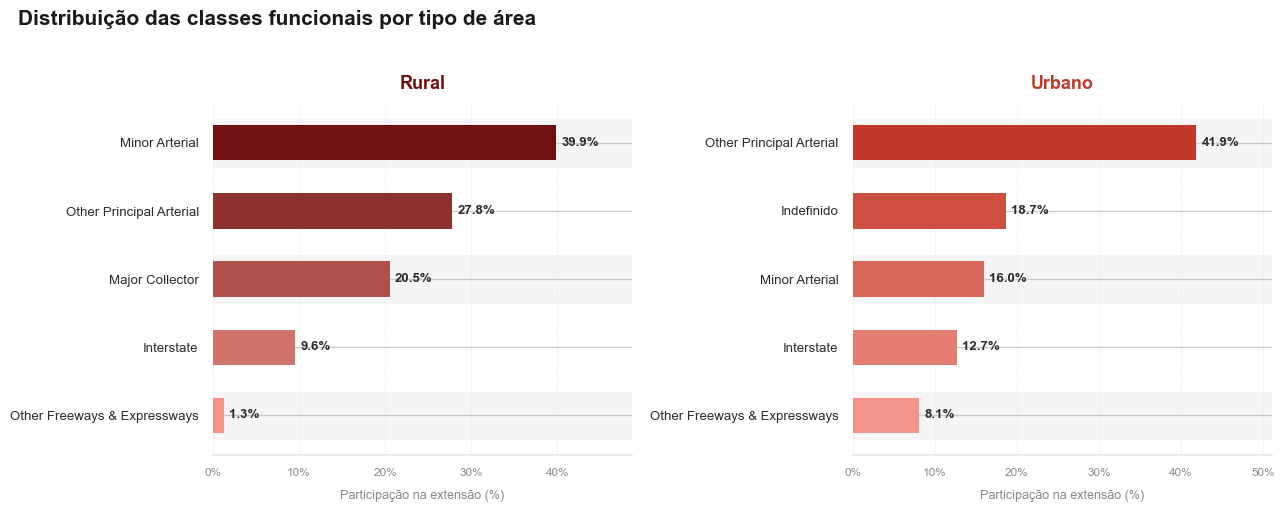

Salvo: nhpn_fsystem_rural_urbano.png


In [27]:
# ── Garantia de mapeamento ────────────────────────────────────────────
if 'f_system_labels' not in globals():
    f_system_labels = {
        1: 'Interstate',
        2: 'Other Freeways & Expressways',
        3: 'Other Principal Arterial',
        4: 'Minor Arterial',
        5: 'Major Collector',
        6: 'Minor Collector',
        7: 'Local',
        0: 'Indefinido'
    }

# ── Preparação ───────────────────────────────────────────────────────
df_ru = df.copy()
df_ru['area_tipo'] = np.where(df_ru['URBAN_CODE'] == 99999, 'Rural', 'Urbano')

df_ru_resumo = (
    df_ru.groupby('area_tipo', dropna=False)
    .agg(segmentos=('area_tipo', 'size'), miles_total=('MILES', 'sum'))
    .reset_index()
)
df_ru_resumo['pct_segmentos']      = 100 * df_ru_resumo['segmentos'] / len(df_ru)
df_ru_resumo['miles_por_segmento'] = df_ru_resumo['miles_total'] / df_ru_resumo['segmentos']

ru_fsystem = (
    df_ru.groupby(['area_tipo', 'F_SYSTEM'], dropna=False)
    .agg(segmentos=('F_SYSTEM', 'size'), miles_total=('MILES', 'sum'))
    .reset_index()
)
ru_fsystem['classe'] = ru_fsystem['F_SYSTEM'].map(f_system_labels).fillna('Outra')
ru_fsystem['pct_miles_area'] = (
    ru_fsystem['miles_total']
    / ru_fsystem.groupby('area_tipo')['miles_total'].transform('sum') * 100
)

display(
    ru_fsystem.sort_values(['area_tipo', 'miles_total'], ascending=[True, False])
    .groupby('area_tipo', group_keys=False)
    .head(8)[['area_tipo', 'classe', 'segmentos', 'miles_total', 'pct_miles_area']]
)

plot_ru = (
    ru_fsystem.sort_values(['area_tipo', 'miles_total'], ascending=[True, False])
    .groupby('area_tipo', group_keys=False)
    .head(5)
    .copy()
)

# ── Estilo ───────────────────────────────────────────────────────────
BG     = '#FFFFFF'
DARK   = '#1A1A1A'
MID    = '#2C2C2C'
SUBTLE = '#888888'
GRID   = '#E8E8E8'

C_RURAL  = '#6E1010'   # borgonha
C_URBANO = '#C0392B'   # vermelho vivo

areas   = ['Rural', 'Urbano']
cores   = {'Rural': C_RURAL, 'Urbano': C_URBANO}
n_areas = len(areas)

fig, axes = plt.subplots(1, n_areas, figsize=(13, 5), sharey=False)
fig.patch.set_facecolor(BG)

for ax, area in zip(axes, areas):
    dados = (
        plot_ru[plot_ru['area_tipo'] == area]
        .sort_values('pct_miles_area', ascending=True)
    )
    cor   = cores[area]
    n     = len(dados)

    # Gradiente claro → escuro dentro de cada painel
    from matplotlib.colors import LinearSegmentedColormap
    cmap  = LinearSegmentedColormap.from_list('panel', ['#F1948A', cor])
    pal   = [cmap(i / max(n - 1, 1)) for i in range(n)]

    ax.set_facecolor(BG)

    # Faixas zebradas
    for i in range(n):
        if i % 2 == 0:
            ax.axhspan(i - 0.35, i + 0.35, color='#F5F5F5', zorder=0)

    bars = ax.barh(
        dados['classe'],
        dados['pct_miles_area'],
        color=pal,
        height=0.52,
        edgecolor='none',
        zorder=2,
    )

    # Rótulos
    max_val = dados['pct_miles_area'].max()
    for bar, val in zip(bars, dados['pct_miles_area']):
        ax.text(
            bar.get_width() + max_val * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            va='center', ha='left',
            fontsize=9.5, color=MID, fontweight='bold'
        )

    ax.xaxis.grid(True, linestyle='--', linewidth=0.45, color=GRID, zorder=0)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xlim(right=max_val * 1.22)

    ax.set_title(area, fontsize=13, fontweight='bold', color=cor, pad=10)
    ax.set_xlabel('Participação na extensão (%)', fontsize=9, color=SUBTLE, labelpad=8)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9.5, colors=MID, pad=4)
    ax.tick_params(axis='x', labelsize=8.5, colors=SUBTLE)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color(GRID)

fig.suptitle(
    'Distribuição das classes funcionais por tipo de área',
    fontsize=15, fontweight='bold', color=DARK, y=1.02, x=0.02, ha='left'
)

plt.tight_layout()

fig.savefig(
    'nhpn_fsystem_rural_urbano.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=BG,
    transparent=False
)
plt.show()
print("Salvo: nhpn_fsystem_rural_urbano.png")

## 8) Análise STRAHNET — Rede Estratégica Militar (`STRAHNET`)

A análise abaixo mede a cobertura estratégica por estado e verifica a sobreposição com corredores `Interstate` (`SIGNT1 == I`), para identificar onde há participação estratégica fora da malha interestadual.

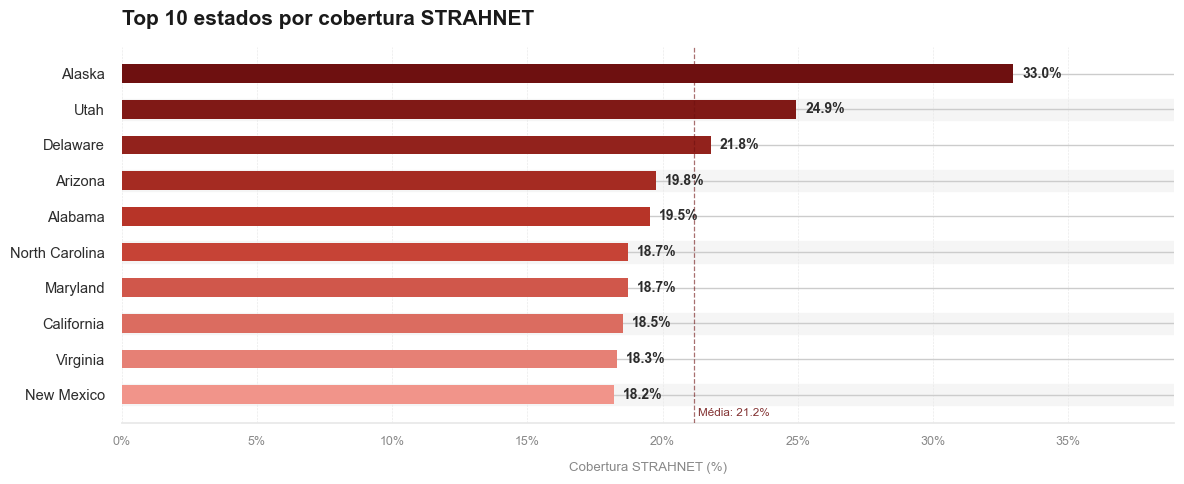

Salvo: nhpn_strahnet_estados.png


In [21]:
# ── Preparação: STRAHNET por estado ─────────────────────────────────
df_st = df.copy()
df_st['is_strahnet'] = df_st['STRAHNET'].fillna(0).astype(float) > 0
strahnet_estado = (
    df_st.groupby('STFIPS', dropna=False)
         .agg(
             miles_total=('MILES', 'sum'),
             miles_strahnet=('MILES', lambda s: s[df_st.loc[s.index, 'is_strahnet']].sum())
         )
         .reset_index()
)
strahnet_estado['pct_miles_strahnet'] = 100 * strahnet_estado['miles_strahnet'] / strahnet_estado['miles_total']
strahnet_estado['estado'] = strahnet_estado['STFIPS'].map(fips_to_state).fillna('Desconhecido')

# ── Paleta opção 2 ───────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

TYPE_COLORS = {'I': '#6E1010', 'US': '#C0392B', 'S': '#F1948A'}
cmap_red = LinearSegmentedColormap.from_list(
    'red_op2', [TYPE_COLORS['S'], TYPE_COLORS['US'], TYPE_COLORS['I']]
)

BG     = '#FFFFFF'
DARK   = '#1A1A1A'
MID    = '#2C2C2C'
SUBTLE = '#888888'
GRID   = '#E8E8E8'

plot_st = (
    strahnet_estado
    .sort_values('pct_miles_strahnet', ascending=False)
    .head(10)
    .sort_values('pct_miles_strahnet', ascending=True)
)

palette = [cmap_red(i / (len(plot_st) - 1)) for i in range(len(plot_st))]

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(
    plot_st['estado'],
    plot_st['pct_miles_strahnet'],
    color=palette,
    height=0.52,
    edgecolor='none',
)

# Faixas zebradas
for i, bar in enumerate(bars):
    if i % 2 == 0:
        ax.axhspan(
            bar.get_y() - 0.04,
            bar.get_y() + bar.get_height() + 0.04,
            color='#F5F5F5', zorder=0
        )

# Linha de referência: média dos top 10
media = plot_st['pct_miles_strahnet'].mean()
ax.axvline(
    media, color='#6E1010', linewidth=0.9,
    linestyle='--', alpha=0.6, zorder=3
)
ax.text(
    media + plot_st['pct_miles_strahnet'].max() * 0.005,
    -0.6,
    f'Média: {media:.1f}%',
    fontsize=8.5, color='#6E1010', alpha=0.85
)

ax.xaxis.grid(True, linestyle='--', linewidth=0.45, color=GRID, alpha=1, zorder=0)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Rótulos: só percentual
for bar, pct in zip(bars, plot_st['pct_miles_strahnet']):
    ax.text(
        bar.get_width() + plot_st['pct_miles_strahnet'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', ha='left',
        fontsize=10, color=MID, fontweight='bold'
    )

# ── Títulos ───────────────────────────────────────────────────────────
ax.set_title(
    'Top 10 estados por cobertura STRAHNET',
    fontsize=15, fontweight='bold', color=DARK,
    pad=16, loc='left', x=0.0
)

ax.set_xlabel('Cobertura STRAHNET (%)', fontsize=9.5, color=SUBTLE, labelpad=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10.5, colors=MID, pad=6)
ax.tick_params(axis='x', labelsize=9, colors=SUBTLE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(right=plot_st['pct_miles_strahnet'].max() * 1.18)

plt.tight_layout()

fig.savefig(
    'nhpn_strahnet_estados.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=BG,
    transparent=False
)

plt.show()
print("Salvo: nhpn_strahnet_estados.png")

## 14) Grafo de Conectividade da Rede (`ROUTE_ID` + `BEGMP` / `ENDMP`)

Sem geometria explícita de nós/arestas, aproximamos a topologia linear por rota ordenando os segmentos por `BEGMP`. Com isso, auditamos continuidade por diferença entre o `ENDMP` de um segmento e o `BEGMP` do próximo.

Critérios adotados:
- **Contínuo**: diferença em valor absoluto <= tolerância.
- **Lacuna (gap)**: próximo `BEGMP` > `ENDMP` + tolerância.
- **Sobreposição**: próximo `BEGMP` < `ENDMP` - tolerância.
- **Segmento órfão**: sem continuidade nem com anterior nem com próximo (ou rota com apenas 1 segmento).

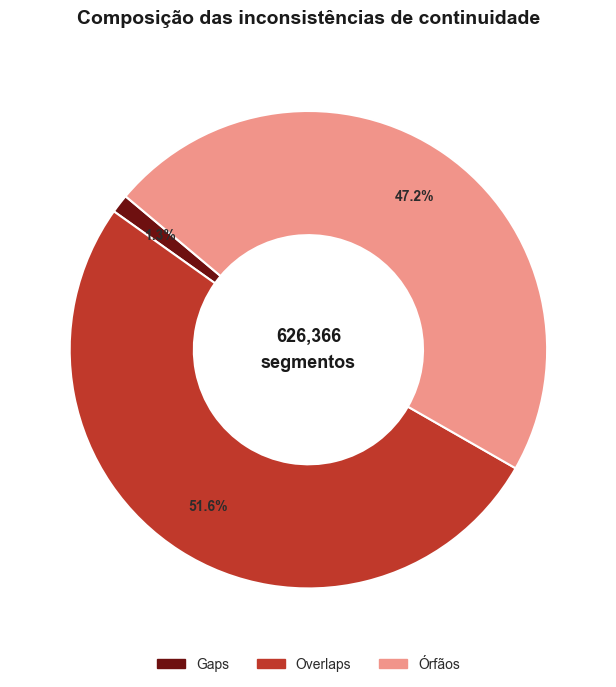

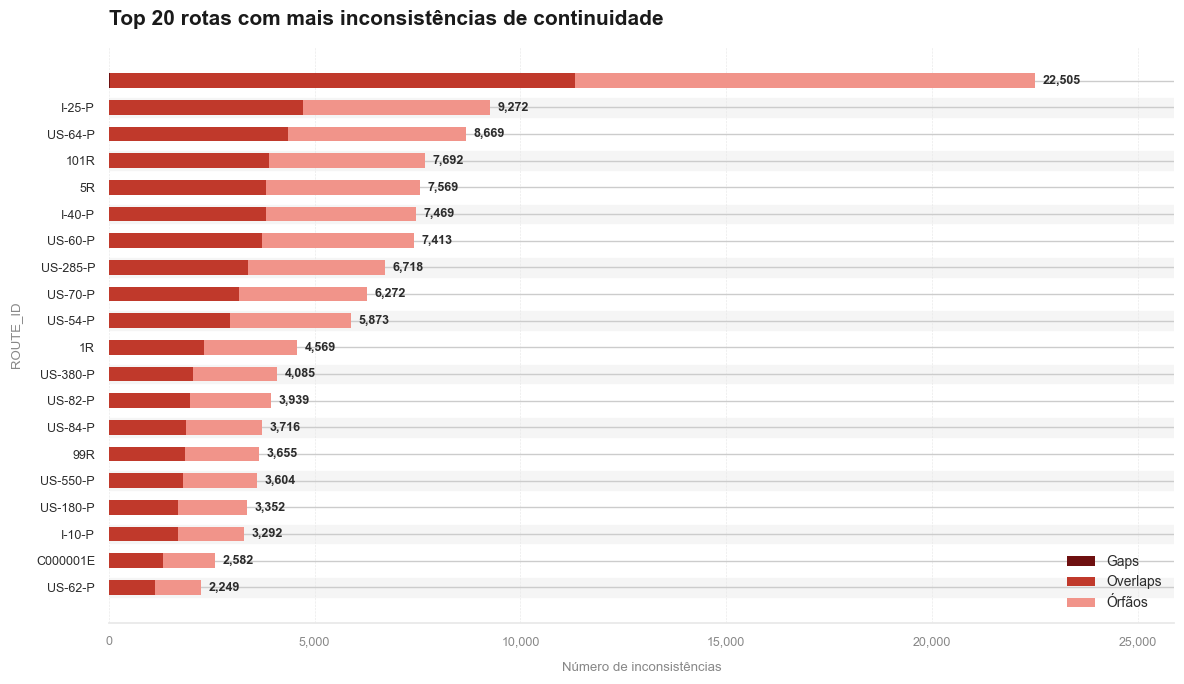

Salvos: nhpn_donut_inconsistencias.png · nhpn_top20_rotas_inconsistencias.png


In [25]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

# ── Paleta opção 2 + extensões para 4 categorias ─────────────────────
TYPE_COLORS = {'I': '#6E1010', 'US': '#C0392B', 'S': '#F1948A'}
C_GAP      = '#6E1010'   # borgonha  — gap
C_OVERLAP  = '#C0392B'   # vermelho  — overlap
C_ORFAO    = '#F1948A'   # salmão    — órfão
C_CONT     = '#E8E8E8'   # cinza     — contínuo

BG     = '#FFFFFF'
DARK   = '#1A1A1A'
MID    = '#2C2C2C'
SUBTLE = '#888888'
GRID   = '#E8E8E8'

# ── Valores ───────────────────────────────────────────────────────────
n_gaps     = int(resumo_conect['gaps_entre_segmentos'].values[0])
n_overlaps = int(resumo_conect['overlaps_entre_segmentos'].values[0])
n_orfaos   = int(resumo_conect['segmentos_orfaos'].values[0])
n_total    = int(resumo_conect['segmentos_analisados'].values[0])
n_cont     = max(0, n_total - n_gaps - n_overlaps - n_orfaos)  # nunca negativo

labels  = ['Gaps', 'Overlaps', 'Órfãos', 'Contínuos']
valores = [n_gaps, n_overlaps, n_orfaos, n_cont]
cores   = [C_GAP, C_OVERLAP, C_ORFAO, C_CONT]

# Remove categorias com valor zero (causam wedge inválido)
dados = [(l, v, c) for l, v, c in zip(labels, valores, cores) if v > 0]
labels  = [d[0] for d in dados]
valores = [d[1] for d in dados]
cores   = [d[2] for d in dados]

# ════════════════════════════════════════════════════════════════════
# Gráfico 1 — Donut
# ════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(7, 7))
fig1.patch.set_facecolor(BG)
ax1.set_facecolor(BG)

wedges, texts, autotexts = ax1.pie(
    valores,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 0.5 else '',
    colors=cores,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_color(MID)
    at.set_fontweight('bold')

# Total no centro
ax1.text(0, 0, f'{n_total:,}\nsegmentos', ha='center', va='center',
         fontsize=13, fontweight='bold', color=DARK, linespacing=1.6)

# Legenda manual
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(cores, labels)]
ax1.legend(
    handles=patches, loc='lower center', ncol=4,
    bbox_to_anchor=(0.5, -0.06),
    frameon=False, fontsize=10,
    labelcolor=MID
)

ax1.set_title(
    'Composição das inconsistências de continuidade',
    fontsize=14, fontweight='bold', color=DARK, pad=20
)

plt.tight_layout()
fig1.savefig('nhpn_donut_inconsistencias.png', dpi=180,
             bbox_inches='tight', facecolor=BG)
plt.show()

# ════════════════════════════════════════════════════════════════════
# Gráfico 2 — Top 20 rotas · barras empilhadas horizontais
# ════════════════════════════════════════════════════════════════════
top20 = (
    route_qc.sort_values('inconsistencias_total', ascending=False)
            .head(20)
            .sort_values('inconsistencias_total', ascending=True)
)

fig2, ax2 = plt.subplots(figsize=(12, 7))
fig2.patch.set_facecolor(BG)
ax2.set_facecolor(BG)

# Faixas zebradas
for i in range(len(top20)):
    if i % 2 == 0:
        ax2.axhspan(i - 0.35, i + 0.35, color='#F5F5F5', zorder=0)

categorias = [
    ('gaps',     'Gaps',     C_GAP),
    ('overlaps', 'Overlaps', C_OVERLAP),
    ('orfaos',   'Órfãos',   C_ORFAO),
]

left = np.zeros(len(top20))
bar_groups = {}
for col, label, cor in categorias:
    vals = top20[col].values
    bars = ax2.barh(
        top20['ROUTE_ID'].astype(str),
        vals,
        left=left,
        color=cor,
        height=0.55,
        edgecolor='none',
        label=label,
        zorder=2,
    )
    bar_groups[col] = (bars, vals)
    left += vals

# Rótulo do total no fim de cada barra
for i, total in enumerate(top20['inconsistencias_total']):
    ax2.text(
        total + top20['inconsistencias_total'].max() * 0.008,
        i,
        f'{int(total):,}',
        va='center', ha='left',
        fontsize=9, color=MID, fontweight='bold'
    )

ax2.xaxis.grid(True, linestyle='--', linewidth=0.45, color=GRID, alpha=1, zorder=0)
ax2.set_axisbelow(True)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2.set_title(
    'Top 20 rotas com mais inconsistências de continuidade',
    fontsize=15, fontweight='bold', color=DARK, pad=16, loc='left'
)
ax2.set_xlabel('Número de inconsistências', fontsize=9.5, color=SUBTLE, labelpad=10)
ax2.set_ylabel('ROUTE_ID', fontsize=9.5, color=SUBTLE, labelpad=10)
ax2.tick_params(axis='y', labelsize=9, colors=MID, pad=4)
ax2.tick_params(axis='x', labelsize=9, colors=SUBTLE)
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.spines['bottom'].set_color(GRID)
ax2.set_xlim(right=top20['inconsistencias_total'].max() * 1.15)

ax2.legend(
    loc='lower right', frameon=False,
    fontsize=10, labelcolor=MID
)

plt.tight_layout()
fig2.savefig('nhpn_top20_rotas_inconsistencias.png', dpi=180,
             bbox_inches='tight', facecolor=BG)
plt.show()
print("Salvos: nhpn_donut_inconsistencias.png · nhpn_top20_rotas_inconsistencias.png")

## 15) Síntese executiva para gestão (gerada a partir da base)

Esta seção transforma os resultados técnicos da EDA em uma leitura orientada à decisão gerencial.

Como ler:

- **Painel executivo**: principais indicadores com interpretação de negócio.
- **Leituras para decisão**: mensagens-chave para priorização.
- **Backlog 90 dias**: iniciativas recomendadas para execução imediata.


In [13]:
# ── Preparação (defensiva): garante variáveis essenciais ────────────
if 'extensao_fsystem' not in globals():
    f_system_labels = {
        1: 'Interstate',
        2: 'Other Freeways & Expressways',
        3: 'Other Principal Arterial',
        4: 'Minor Arterial',
        5: 'Major Collector',
        6: 'Minor Collector',
        7: 'Local',
        0: 'Indefinido'
    }
    extensao_fsystem = (
        df.groupby('F_SYSTEM', dropna=False)
          .agg(MILES=('MILES', 'sum'), KM=('KM', 'sum'))
          .assign(classe=lambda d: d.index.map(lambda x: f_system_labels.get(int(x), 'Outra')))
          .sort_values('MILES', ascending=False)
    )
    extensao_fsystem['pct_miles'] = 100 * extensao_fsystem['MILES'] / extensao_fsystem['MILES'].sum()

if 'extensao_estado' not in globals():
    extensao_estado = (
        df.groupby('STFIPS', dropna=False)
          .agg(MILES=('MILES', 'sum'), KM=('KM', 'sum'))
          .sort_values('KM', ascending=False)
    )

if 'nhs_ext' not in globals():
    nhs_ext = (
        df.groupby('NHS', dropna=False)
          .agg(MILES=('MILES', 'sum'), trechos=('NHS', 'size'))
          .sort_values('MILES', ascending=False)
    )
    nhs_ext['pct_miles'] = 100 * nhs_ext['MILES'] / nhs_ext['MILES'].sum()

if 'share_trechos' not in globals() or 'share_milhas' not in globals():
    sign_norm = df['SIGNT1'].astype(str).str.upper().str.strip()
    corredores = df.loc[sign_norm.isin({'I', 'US'})]
    share_trechos = len(corredores) / len(df)
    share_milhas = corredores['MILES'].sum() / df['MILES'].sum()

geom = df[['MILES', 'KM']].copy()
geom['MILES_nozero'] = geom['MILES'].replace(0, np.nan)
geom['ratio_km_miles'] = geom['KM'] / geom['MILES_nozero']
geom['erro_abs_km'] = (geom['KM'] - geom['MILES'] * 1.60934).abs()

# ── Consolidação executiva ───────────────────────────────────────────
total_segmentos = len(df)
total_km = df['KM'].sum()

classe_top = extensao_fsystem.iloc[0]
classe_top_nome = classe_top['classe']
classe_top_pct = float(classe_top['pct_miles'])

estado_top = extensao_estado.head(1).reset_index().iloc[0]
estado_top_nome = fips_to_state.get(int(estado_top['STFIPS']), 'Estado desconhecido')
estado_top_km = float(estado_top['KM'])

nhs1_pct = float(nhs_ext.loc[1, 'pct_miles']) if 1 in nhs_ext.index else np.nan
corr_trechos_pct = 100 * share_trechos
corr_milhas_pct = 100 * share_milhas
ratio_mediana = float(geom['ratio_km_miles'].median())
erro_p99_km = float(geom['erro_abs_km'].quantile(0.99))

if 'resumo_conect' in globals() and len(resumo_conect) > 0:
    pct_orfaos = float(resumo_conect.loc[0, 'pct_orfaos'])
    gaps = int(resumo_conect.loc[0, 'gaps_entre_segmentos'])
    overlaps = int(resumo_conect.loc[0, 'overlaps_entre_segmentos'])
else:
    pct_orfaos = np.nan
    gaps = np.nan
    overlaps = np.nan

painel_executivo = pd.DataFrame([
    {
        'Dimensão': 'Escala da rede',
        'Indicador': 'Base analisada',
        'Resultado': f'{total_segmentos:,.0f} segmentos e {total_km:,.0f} km',
        'Leitura para gestão': 'Há massa crítica para priorização nacional e segmentação por estado/corredor.'
    },
    {
        'Dimensão': 'Hierarquia funcional',
        'Indicador': 'Classe de maior extensão',
        'Resultado': f"{classe_top_nome} ({classe_top_pct:.2f}% das milhas)",
        'Leitura para gestão': 'É a classe com maior peso estrutural; deve liderar critérios de investimento e monitoramento.'
    },
    {
        'Dimensão': 'Concentração territorial',
        'Indicador': 'Estado de maior extensão',
        'Resultado': f"{estado_top_nome} ({estado_top_km:,.0f} km)",
        'Leitura para gestão': 'Recomenda carteira dedicada por estado para evitar alocação homogênea ineficiente.'
    },
    {
        'Dimensão': 'Corredores estratégicos',
        'Indicador': 'Participação I/US',
        'Resultado': f'{corr_trechos_pct:.2f}% dos trechos e {corr_milhas_pct:.2f}% da extensão',
        'Leitura para gestão': 'Corredores troncais têm alto impacto sistêmico e devem ter plano de continuidade operacional.'
    },
    {
        'Dimensão': 'Rede federal (NHS)',
        'Indicador': 'Peso do NHS == 1',
        'Resultado': f'{nhs1_pct:.2f}% da extensão',
        'Leitura para gestão': 'Separar carteira NHS vs não-NHS facilita estratégia de funding e governança de projetos.'
    },
    {
        'Dimensão': 'Qualidade de dados',
        'Indicador': 'Consistência KM/MILES',
        'Resultado': f'mediana {ratio_mediana:.6f} | P99 erro {erro_p99_km:.6f} km',
        'Leitura para gestão': 'Base com boa confiabilidade métrica para análises comparativas e indicadores executivos.'
    },
    {
        'Dimensão': 'Risco operacional de rede',
        'Indicador': 'Continuidade linear aproximada',
        'Resultado': f'Órfãos: {pct_orfaos:.2f}% | Gaps: {gaps:,.0f} | Overlaps: {overlaps:,.0f}',
        'Leitura para gestão': 'Há sinais de inconsistência topológica; antes de roteamento, priorizar saneamento da malha.'
    }
])

print('RESUMO EXECUTIVO (LEITURA DE 1 MINUTO)\n')
print(f'- A malha analisada soma {total_km:,.0f} km em {total_segmentos:,.0f} segmentos.')
print(f"- A hierarquia é liderada por '{classe_top_nome}' ({classe_top_pct:.2f}% das milhas).")
print(f'- {estado_top_nome} concentra a maior extensão absoluta ({estado_top_km:,.0f} km).')
print(f'- Corredores I/US representam {corr_trechos_pct:.2f}% dos trechos e {corr_milhas_pct:.2f}% da extensão.')
print(f'- O recorte NHS principal responde por {nhs1_pct:.2f}% da extensão total.')
if not np.isnan(pct_orfaos):
    print(f'- Continuidade: {pct_orfaos:.2f}% de segmentos órfãos, com {gaps:,.0f} gaps e {overlaps:,.0f} overlaps.')
print(f'- A consistência métrica está alta (P99 do erro KM/MILES = {erro_p99_km:.6f} km).')

print('\nPAINEL EXECUTIVO')
display(painel_executivo)

backlog_90_dias = pd.DataFrame([
    {
        'Prioridade': 'Alta',
        'Frente': 'Governança de dados',
        'Ação recomendada (90 dias)': 'Implementar rotina de QA topológico (gaps, overlaps, órfãos) por estado e por rota.',
        'Resultado esperado': 'Queda de inconsistências críticas e maior confiabilidade para análises de rede.'
    },
    {
        'Prioridade': 'Alta',
        'Frente': 'Planejamento de investimento',
        'Ação recomendada (90 dias)': 'Criar carteira priorizada cruzando F_SYSTEM, NHS/STRAHNET e extensão por estado.',
        'Resultado esperado': 'Pipeline de projetos orientado a impacto logístico e elegibilidade de funding.'
    },
    {
        'Prioridade': 'Média',
        'Frente': 'Performance territorial',
        'Ação recomendada (90 dias)': 'Definir dashboard executivo com KPIs por estado (km, share I/US, share NHS, risco de continuidade).',
        'Resultado esperado': 'Monitoramento contínuo para decisão trimestral baseada em indicadores padronizados.'
    }
])

print('BACKLOG RECOMENDADO (90 DIAS)')
display(backlog_90_dias)


RESUMO EXECUTIVO (LEITURA DE 1 MINUTO)

- A malha analisada soma 703,110 km em 626,366 segmentos.
- A hierarquia é liderada por 'Minor Arterial' (32.87% das milhas).
- Texas concentra a maior extensão absoluta (54,760 km).
- Corredores I/US representam 15.47% dos trechos e 10.68% da extensão.
- O recorte NHS principal responde por 10.69% da extensão total.
- Continuidade: 59.19% de segmentos órfãos, com 10,004 gaps e 405,354 overlaps.
- A consistência métrica está alta (P99 do erro KM/MILES = 0.001174 km).

PAINEL EXECUTIVO


,Dimensão,Indicador,Resultado,Leitura para gestão
0,Escala da rede,Base analisada,"626,366 segmentos e 703,110 km",Há massa crítica para priorização nacional e s...
1,Hierarquia funcional,Classe de maior extensão,Minor Arterial (32.87% das milhas),É a classe com maior peso estrutural; deve lid...
2,Concentração territorial,Estado de maior extensão,"Texas (54,760 km)",Recomenda carteira dedicada por estado para ev...
3,Corredores estratégicos,Participação I/US,15.47% dos trechos e 10.68% da extensão,Corredores troncais têm alto impacto sistêmico...
4,Rede federal (NHS),Peso do NHS == 1,10.69% da extensão,Separar carteira NHS vs não-NHS facilita estra...
5,Qualidade de dados,Consistência KM/MILES,mediana 1.609354 | P99 erro 0.001174 km,Base com boa confiabilidade métrica para análi...
6,Risco operacional de rede,Continuidade linear aproximada,"Órfãos: 59.19% | Gaps: 10,004 | Overlaps: 405,354",Há sinais de inconsistência topológica; antes ...


BACKLOG RECOMENDADO (90 DIAS)


,Prioridade,Frente,Ação recomendada (90 dias),Resultado esperado
0,Alta,Governança de dados,"Implementar rotina de QA topológico (gaps, ove...",Queda de inconsistências críticas e maior conf...
1,Alta,Planejamento de investimento,"Criar carteira priorizada cruzando F_SYSTEM, N...",Pipeline de projetos orientado a impacto logís...
2,Média,Performance territorial,Definir dashboard executivo com KPIs por estad...,Monitoramento contínuo para decisão trimestral...
